# 05 — Rough Bergomi: the skew power law

Gatheral, Jaisson & Rosenbaum (2018): realized volatility behaves like fractional Brownian
motion with Hurst exponent $H \approx 0.1$ — *rougher* than any diffusion. The
option-market fingerprint (Fukasawa 2011) is the ATM skew

$$\psi(T) = \left.\frac{\partial \sigma_{IV}}{\partial k}\right|_{k=0} \sim T^{\,H - 1/2},$$

which **explodes** as $T \to 0$ in index-option data. Any classical stochastic-volatility
model (Heston included) saturates to a constant skew at the short end — this is structural,
not a calibration failure. Rough Bergomi (Bayer-Friz-Gatheral 2016) reproduces the power law:

$$v_t = \xi_0 \exp\!\Big(\eta \tilde W_t - \tfrac{1}{2}\eta^2 t^{2H}\Big), \qquad
\tilde W_t = \sqrt{2H} \int_0^t (t-s)^{H - 1/2}\, dW_s,$$

$$dS_t = r\,S_t\,dt + \sqrt{v_t}\,S_t\,\big(\rho\,dW_t + \sqrt{1-\rho^2}\,dW_t^\perp\big).$$

The Volterra process $\tilde W$ is **not Markovian**: no PDE, no characteristic function —
simulation is the only route, and there is no QuantLib-style external benchmark to lean on.
The library therefore implements **two independent simulation schemes** and cross-validates
them against each other:

- **exact joint Cholesky** factorization of the $(W, \tilde W)$ covariance — the internal
  gold standard, expensive but exact;
- the **hybrid scheme** (Bennedsen-Lunde-Pakkanen 2017) — exact treatment of the singular
  kernel on the latest interval, FFT causal convolution elsewhere, $O(N\,n\log n)$;

and prices with the **conditional Black-Scholes estimator** (McCrickerd-Pakkanen 2018): the
orthogonal Brownian dimension is integrated out analytically, with an exact-mean control
variate on the conditional forward.

In [1]:
import sys
import time
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "exotic_option_pricer").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

from exotic_option_pricer.engines import MonteCarloEngine
from exotic_option_pricer.instruments import AsianOption, LookbackOption
from exotic_option_pricer.models import BlackScholesModel, HestonModel, RoughBergomiModel

S0 = 100.0
rb = RoughBergomiModel(xi0=0.04, eta=1.9, H=0.1, rho=-0.9)

# Conditional-BS estimator vs plain payoff MC: two estimators, one price
p_cond = float(rb.price(S0, 100.0, 0.5, 0.03, 'call'))
res_plain = rb.price_mc(S0, 100.0, 0.5, 0.03, 'call', seed=123)
z = (p_cond - res_plain.price) / res_plain.std_error
print(f"conditional-BS estimator: {p_cond:.4f}")
print(f"plain payoff MC: {res_plain.price:.4f}  (SE {res_plain.std_error:.4f})")
print(f"agreement z-score: {z:+.2f}")
assert abs(z) < 4

conditional-BS estimator: 5.6652
plain payoff MC: 5.6627  (SE 0.0166)
agreement z-score: +0.16


## What "rough" looks like

Same driving noise, same $\eta$, different $H$: the $H = 0.1$ volatility path jitters at
every scale — its increments decorrelate almost immediately — while $H = 0.4$ is visibly
smoother. Realized-vol data looks like the left panel.

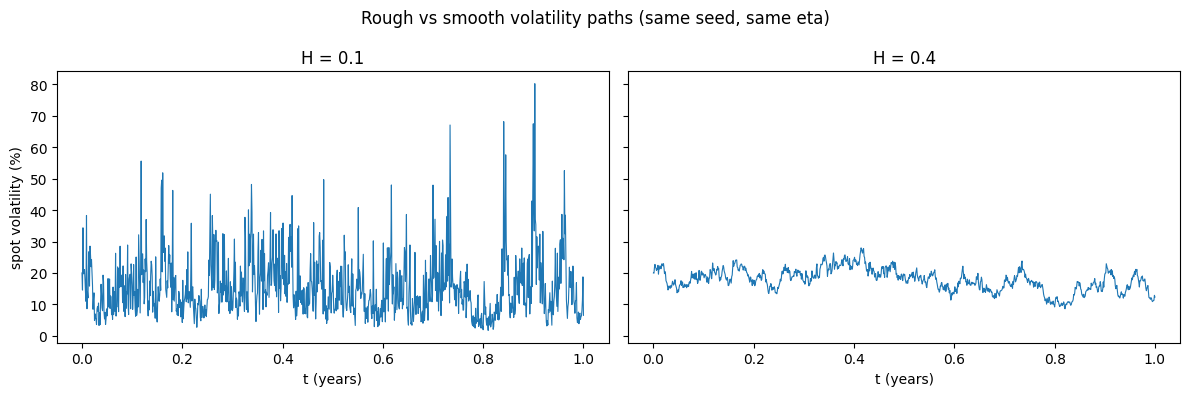

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
t_grid = np.linspace(0.0, 1.0, 1001)
for ax, H_ in zip(axes, (0.1, 0.4)):
    model_h = RoughBergomiModel(xi0=0.04, eta=1.9, H=H_, rho=-0.9)
    _, var_paths = model_h.simulate(S0, 1.0, 0.0, n_paths=2, n_steps=1000,
                                    return_variance=True, seed=11)
    ax.plot(t_grid, 100 * np.sqrt(var_paths[0]), lw=0.8)
    ax.set(title=f'H = {H_}', xlabel='t (years)')
axes[0].set_ylabel('spot volatility (%)')
fig.suptitle('Rough vs smooth volatility paths (same seed, same eta)')
fig.tight_layout()

## Hybrid scheme vs exact Cholesky

The validation that replaces an external benchmark: both schemes must price identically
within Monte Carlo noise, with **independent seeds** (so agreement is not an artifact of
shared randomness).

In [3]:
print(f"{'K':>5} {'Cholesky':>10} {'hybrid':>10} {'z':>6}")
for K in (90.0, 100.0, 110.0):
    r_chol = rb.price_mc(S0, K, 0.5, 0.03, 'call', method='cholesky',
                         n_paths=40_000, n_steps=150, seed=1)
    r_hyb = rb.price_mc(S0, K, 0.5, 0.03, 'call', method='hybrid',
                        n_paths=40_000, n_steps=150, seed=2)
    z = (r_hyb.price - r_chol.price) / np.hypot(r_hyb.std_error, r_chol.std_error)
    print(f"{K:>5.0f} {r_chol.price:>10.4f} {r_hyb.price:>10.4f} {z:>+6.2f}")
    assert abs(z) < 3

    K   Cholesky     hybrid      z


   90    13.0955    13.0700  -0.41


  100     5.6425     5.6224  -0.47


  110     1.0949     1.0870  -0.42


## The experiment: skew power law vs Heston saturation

Methodology (identical to the Phase 5 test suite): ATM skew by a $\pm 0.02$ log-moneyness
stencil, $\psi(T) = [\sigma_{IV}(+k) - \sigma_{IV}(-k)]/2k$, $r = 0$, maturities from
**4 days to 1 year**. The Heston opponent is not a strawman — it is the model **calibrated to
1,718 real SPX options in Phase 4** ($\kappa = 13$, $\xi = 3$: the optimizer pushed
mean reversion to extremes precisely to chase the short-dated skew).

What to expect (measured in the Phase 5 validation):

- rBergomi: log-log slope $\approx -0.43$ over $[0.05, 1]$ **and** $\approx -0.41$ on
  $[0.01, 0.05]$ — one straight line, exponent $H - 1/2$;
- Heston: slope $-0.58$ at the long end (its $1/T$ regime with $\kappa = 13$) but only
  $\approx -0.20$ at the short end — the log-log curve **bends**, skew saturating exactly
  where the market (and rBergomi) explode.

In [4]:
K_OFF = 0.02
Ks = S0 * np.exp(np.array([-K_OFF, K_OFF]))
mats_short = np.array([0.01, 0.02, 0.05])
mats_main = np.array([0.05, 0.10, 0.25, 0.50, 1.00])
mats_all = np.array([0.01, 0.02, 0.05, 0.10, 0.25, 0.50, 1.00])

t0 = time.perf_counter()
ivs_rb = rb.iv_surface(S0, Ks, mats_all, 0.0)
psi_rb = (ivs_rb[:, 1] - ivs_rb[:, 0]) / (2 * K_OFF)
print(f"rBergomi surface ({len(mats_all)} maturities x 131k paths): {time.perf_counter() - t0:.1f}s")

import warnings as _w
with _w.catch_warnings():
    _w.simplefilter('ignore', UserWarning)
    heston_spx = HestonModel(v0=0.033, kappa=13.0, theta=0.048, xi=3.0, rho=-0.64)

def heston_skew(T_):
    ivs = []
    for k in (-K_OFF, K_OFF):
        K_ = S0 * np.exp(k)
        p_ = float(heston_spx.price(S0, K_, float(T_), 0.0, 'call'))
        ivs.append(BlackScholesModel.implied_vol(p_, S0, K_, float(T_), 0.0, 'call'))
    return (ivs[1] - ivs[0]) / (2 * K_OFF)

psi_h = np.array([heston_skew(T_) for T_ in mats_all])

def slope(mats, psi):
    return float(np.polyfit(np.log(mats), np.log(np.abs(psi)), 1)[0])

mask_short = mats_all <= 0.05
mask_main = mats_all >= 0.05
mask_long = mats_all >= 0.25

s_rb_main = slope(mats_all[mask_main], psi_rb[mask_main])
s_rb_short = slope(mats_all[mask_short], psi_rb[mask_short])
s_h_short = slope(mats_all[mask_short], psi_h[mask_short])
s_h_long = slope(mats_all[mask_long], psi_h[mask_long])

print(f"\nrBergomi slope [0.05, 1]: {s_rb_main:+.3f}   (theory H - 1/2 = -0.4)")
print(f"rBergomi slope [0.01, 0.05]: {s_rb_short:+.3f}   (same straight line)")
print(f"Heston slope [0.01, 0.05]: {s_h_short:+.3f}   (saturating)")
print(f"Heston slope [0.25, 1]: {s_h_long:+.3f}   (1/T regime)")
print(f"Heston log-log curvature: {s_h_short - s_h_long:+.2f}  |  rBergomi: {s_rb_short - s_rb_main:+.2f}")

assert -0.5 < s_rb_main < -0.3
assert s_rb_short < -0.33
assert s_h_short > -0.30
assert s_h_short - s_h_long > 0.30

rBergomi surface (7 maturities x 131k paths): 13.7s

rBergomi slope [0.05, 1]: -0.433   (theory H - 1/2 = -0.4)
rBergomi slope [0.01, 0.05]: -0.411   (same straight line)
Heston slope [0.01, 0.05]: -0.201   (saturating)
Heston slope [0.25, 1]: -0.707   (1/T regime)
Heston log-log curvature: +0.51  |  rBergomi: +0.02


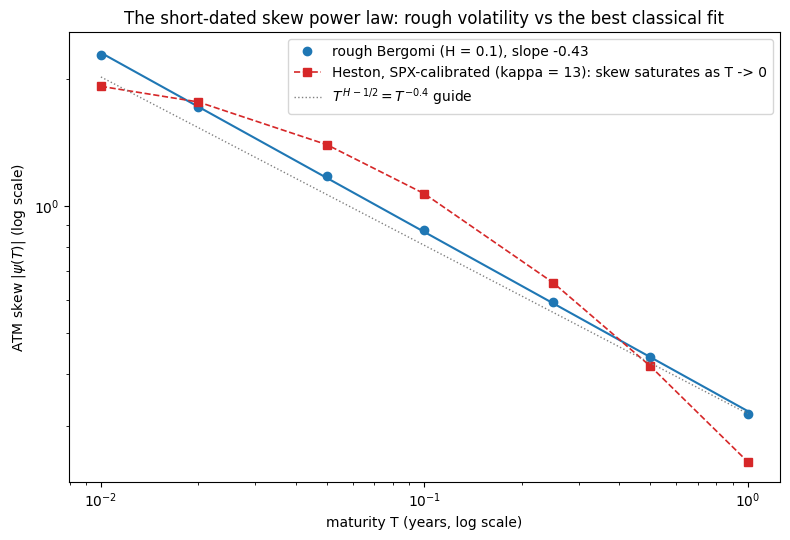

In [5]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.loglog(mats_all, np.abs(psi_rb), 'o', color='C0', ms=6,
          label=f'rough Bergomi (H = 0.1), slope {s_rb_main:.2f}')
fit_rb = np.exp(np.polyval(np.polyfit(np.log(mats_all), np.log(np.abs(psi_rb)), 1), np.log(mats_all)))
ax.loglog(mats_all, fit_rb, '-', color='C0', lw=1.5)
ax.loglog(mats_all, np.abs(psi_h), 's--', color='C3', ms=6, lw=1.2,
          label='Heston, SPX-calibrated (kappa = 13): skew saturates as T -> 0')
guide = np.abs(psi_rb)[-1] * (mats_all / mats_all[-1]) ** (-0.4)
ax.loglog(mats_all, guide, ':', color='gray', lw=1, label=r'$T^{\,H-1/2} = T^{-0.4}$ guide')
ax.set(xlabel='maturity T (years, log scale)', ylabel=r'ATM skew $|\psi(T)|$ (log scale)',
       title='The short-dated skew power law: rough volatility vs the best classical fit')
ax.legend()
fig.tight_layout()

img_dir = ROOT / 'docs' / 'img'
img_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(img_dir / 'skew_power_law.png', dpi=150, bbox_inches='tight')

## Sanity limit and exotics on rough paths

As $\eta \to 0$ the variance freezes at $\xi_0$ and rBergomi must collapse onto the
Phase 1 Black-Scholes engine (the Phase 5 suite pins this to $8.5\times10^{-11}$ with the
control variate making the estimator deterministic). And the Phase 3 instruments price on
rough paths with **zero code changes** — the third model behind the same `payoff(paths)`
contract. At matched ATM vol, the lookback feels the fat volatility clustering of rough
paths through its running extremum.

In [6]:
frozen = RoughBergomiModel(xi0=0.04, eta=1e-8, H=0.3, rho=0.0)
bs_ref = float(BlackScholesModel(sigma=0.20).price(S0, 100.0, 1.0, 0.03, 'call'))
diff = abs(float(frozen.price(S0, 100.0, 1.0, 0.03, 'call')) - bs_ref)
print(f"|rBergomi(eta -> 0) - BS(sigma = 20%)| = {diff:.2e}")
assert diff < 1e-6

|rBergomi(eta -> 0) - BS(sigma = 20%)| = 6.08e-11


In [7]:
sigma_atm = float(rb.iv_surface(S0, np.array([100.0]), np.array([1.0]), 0.03)[0, 0])
engine = MonteCarloEngine(n_paths=100_000, n_steps=252, seed=42)
gbm_paths = engine.simulate_gbm(S0, 1.0, 0.03, sigma_atm)
rb_paths = rb.simulate(S0, 1.0, 0.03, n_paths=100_000, n_steps=252, seed=42)

asian = AsianOption(K=100.0, option_type='call')
lookback = LookbackOption(option_type='call', strike_type='floating')

print(f"matched GBM vol: {100 * sigma_atm:.2f}%\n")
print(f"{'instrument':>22} {'GBM':>9} {'rBergomi':>9} {'diff/SE':>8}")
for name, inst in (('Asian call', asian), ('lookback (floating)', lookback)):
    r_gbm = engine.price(inst.payoff, gbm_paths, 0.03, 1.0)
    r_rb = engine.price(inst.payoff, rb_paths, 0.03, 1.0)
    se = np.hypot(r_gbm.std_error, r_rb.std_error)
    print(f"{name:>22} {r_gbm.price:>9.4f} {r_rb.price:>9.4f} {(r_rb.price - r_gbm.price) / se:>+8.1f}")

matched GBM vol: 17.25%

            instrument       GBM  rBergomi  diff/SE
            Asian call    4.6947    4.8004     +4.0
   lookback (floating)   13.8822   15.5120    +34.7


---
That closes the modelling arc: analytical Black-Scholes (01), a validated Monte Carlo engine
(02), exotics with closed-form cross-checks (03), Heston with QuantLib-pinned Fourier pricing
and live-data calibration (04), and rough volatility validated scheme-against-scheme where no
external benchmark exists (05) — 977 tests, 97% coverage, every claim measured.